# Beyond BLAST

In [1]:
ENV["JULIA_PKG_PRECOMPILE_AUTO"] = 0;
using Pkg
Pkg.activate("blast_code"; io=devnull)
Pkg.resolve(; io=devnull)
Pkg.instantiate(; io=devnull)

using Revise 
using Base.Threads, NPZ, DataInterpolations, Interpolations, FastChebInterp
using BenchmarkTools, FFTW, FastTransforms, Dates, TOML, Plots, Plots.Measures
using QuadGK, LaTeXStrings, Tullio, StaticArrays, LoopVectorization, LinearAlgebra
using Unitful, SpecialFunctions, DifferentialEquations, Cosmology, NumericalIntegration
using CSV, DataFrames, JSON;

[ Info: Precompiling DataInterpolations [82cc6244-b520-54b8-b5a6-8a565e85f1d0]
Precompiling packages...
   2029.4 ms  ✓ DataInterpolations → DataInterpolationsChainRulesCoreExt
  1 dependency successfully precompiled in 3 seconds. 37 already precompiled.
[ Info: Precompiling DataInterpolationsChainRulesCoreExt [187dfacc-d000-5da0-94aa-5ec8eb045cfd]
┌ Warning: Module DataInterpolations with build ID fafbfcfd-678d-013a-edab-62411a1c1ebe is missing from the cache.
│ This may mean DataInterpolations [82cc6244-b520-54b8-b5a6-8a565e85f1d0] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:2022
[ Info: Skipping precompilation since __precompile__(false). Importing DataInterpolationsChainRulesCoreExt [187dfacc-d000-5da0-94aa-5ec8eb045cfd].
Precompiling packages...
    585.1 ms  ✓ FastChebInterp
  1 dependency successfully precompiled in 1 seconds. 18 already precompiled.
[ Info: Precompiling FastChebInterp [cf66c380-9a80-432c-aff8-4f9c79c0bdde]
Precompi

In [11]:
includet("blast_code/src/Blast.jl")
includet("blast_code/src/blast_tutorials.jl")
using .Blast
using .blast_tutorials

includet("blast_code/src/galaxy_galaxy.jl")
includet("blast_code/src/shear_shear.jl")
using .galaxy_galaxy
using .shear_shear

┌ Warning: Replacing docs for `Main.Blast.AbstractCosmology :: Union{}` in module `Main.Blast`
└ @ Base.Docs docs/Docs.jl:243
┌ Warning: Replacing docs for `Main.Blast.AbstractCosmologicalGrid :: Union{}` in module `Main.Blast`
└ @ Base.Docs docs/Docs.jl:243
┌ Warning: Replacing docs for `Main.Blast.AbstractBackgroundQuantities :: Union{}` in module `Main.Blast`
└ @ Base.Docs docs/Docs.jl:243
┌ Warning: Replacing docs for `Main.Blast.AbstractCosmologicalProbes :: Union{}` in module `Main.Blast`
└ @ Base.Docs docs/Docs.jl:243
┌ Warning: Replacing docs for `Main.Blast.FlatΛCDM :: Union{}` in module `Main.Blast`
└ @ Base.Docs docs/Docs.jl:243
┌ Warning: Replacing docs for `Main.Blast.CosmologicalGrid :: Union{}` in module `Main.Blast`
└ @ Base.Docs docs/Docs.jl:243
┌ Warning: Replacing docs for `Main.Blast.BackgroundQuantities :: Union{}` in module `Main.Blast`
└ @ Base.Docs docs/Docs.jl:243
┌ Warning: Replacing docs for `Main.Blast.GalaxyKernel :: Union{}` in module `Main.Blast`
└ @ Base

In [12]:
timestamp = Dates.format(now(), "yyyy_mm_dd_HHMMSS")
output_dir = "out/runs/run_$timestamp"
plot_subdir = joinpath(output_dir, "plots")
Sl_plots = joinpath(plot_subdir, "Sl_plots")
Kernel_plots = joinpath(plot_subdir, "kernels")
quantity_subdir = joinpath(output_dir, "quantities")
chebcoefs = joinpath(quantity_subdir, "chebcoefs")
Sl = joinpath(quantity_subdir, "Sl")
mkpath(output_dir)
mkpath(plot_subdir)
mkpath(quantity_subdir)
mkpath(chebcoefs)
mkpath(Sl)
mkpath(Sl_plots)
mkpath(Kernel_plots)
println("Folders in place: ", output_dir, ", ", plot_subdir, " and ", quantity_subdir)

Folders in place: out/runs/run_2026_06_25_153308, out/runs/run_2026_06_25_153308/plots and out/runs/run_2026_06_25_153308/quantities


### Getting background quantities:

redshift $z$, comoving distance $\chi(z)$

In [13]:
#Background quantities
z_b = npzread("blast_code/data/background/z.npy") # array 
χ_b = npzread("blast_code/data/background/chi.npy") # array 
# using Akima interpolation
z_of_χ = DataInterpolations.AkimaInterpolation(z_b, χ_b); # z(χ)
chi_of_z = DataInterpolations.AkimaInterpolation(χ_b, z_b); # χ(z)

#### Setting parameters

In [14]:
cosmo = Blast.FlatΛCDM()
n_chi = 96                                            # Number of comoving distance points
x_range = LinRange(26, 7000, n_chi)                   # in Mpc/h: from 26 Mpc/h to 7000 Mpc/h
z_range = z_of_χ.(x_range)
#ℓ = Blast.ℓ
ℓ = LinRange(2, 200, 100)
x_min = minimum(x_range)                              # minimum comoving distance [Mpc/h]
x_max = maximum(x_range)                              # maximum comoving distance [Mpc/h]
chi = LinRange(x_min, x_max, n_chi)                   # array of comoving distances [Mpc/h]
zed = z_of_χ.(chi)                                    # array of redshifts corresponding to the comoving distances
n_z = length(zed)
n5k_bins = npzread("blast_code/data/dNdzs_fullwidth.npz")
z_n5k = n5k_bins["z_cl"]
zmin = minimum(z_n5k)                                 # minimum redshift
zmax = maximum(z_n5k)                                 # maximum redshift
kmax = 200/13                                         # maximum wavenumber (small scales) [h/Mpc]
kmin = 2.5/x_max                                      # minimum wavenumber (large scales) [h/Mpc]
n_cheb = 119                                          # number of Chebyshev nodes 
β = 2                                                 # exponent depending on the probe: 0 for Galaxy - Shear, 2 for Galaxy - Galaxy, -2 for Shear - Shear
k_cheb = chebpoints(n_cheb, log10(kmin), log10(kmax)) # number of Chebyshev "points"
N = 2^15+1;

In [15]:
shear_prefac_W = shear_shear.shear_prefactor(x_range, z_range, cosmo; output_dir=output_dir);
shear_prefac_W_cheb = shear_shear.shear_prefactor_cheb(zmin, zmax, n_cheb, z_range, shear_prefac_W; output_dir=output_dir);
cheb_coeff_shear = shear_shear.compute_prefactor_chebcoeffs(shear_prefac_W_cheb; output_dir=output_dir);

Plot saved: out/runs/run_2026_06_25_153308/plots/kernels/chi_vs_z_shear.png
Plot saved: out/runs/run_2026_06_25_153308/plots/kernels/nz_shear.png
Plot saved: out/runs/run_2026_06_25_153308/plots/kernels/lensing_efficiency.png
Wrote W(z) shear prefactor on Chebyshev grid to: out/runs/run_2026_06_25_153308/quantities/prefac_on_cheb_shear.npy
Wrote W(z) Chebyshev coefficients to: out/runs/run_2026_06_25_153308/quantities/W_cheb_coeff_shear.npy


Defining the kernel/window function for a galaxy probe: the window function is \
\
$W(z) = n(z) \chi(z)^2 b(z) D(z) $ \
\
where \
\
$n(z) = A (\frac{z}{z_0})^{\alpha} exp[{-(\frac{z}{z_0})^{\beta}}] $, with $A = \frac{1.5}{z_0}$, $\alpha = 2$ and $\beta = 1.5$ \
\
$b(z) = b_0 \sqrt{1+z} $ and $b_0 = 1$ \
\
$D(z) = \frac{D(z)^{unnorm}}{D(0)^{unnorm}}$, with $D(z)^{unnorm} = E(z) \int_z^{\infty} dz' \frac{1+z'}{E(z')^3} $ 

As for the ````gal_prefactor_W_cheb````, it is obtained interpolating each factor, ````bias````, ````growth````, ````nz_norm````, ````chi```` on the ````z_range````, and then obtaining the total interpolated product ````gal_prefact_W_cheb````.

As for the ````cheb_coeff_gal````, I compute this similarly to Blast: I define a ````plan```` object that takes the ````gal_prefact_W_cheb```` as input, and then returns the ````cheb_coeff```` as the output of the functions ````fast_chebcoefs````

In [16]:
gal_prefact_W, bias, growth, inv_Hubble, nz_norm = galaxy_galaxy.galaxy_prefactor(x_range, z_range, cosmo; output_dir=output_dir);
gal_prefact_W_cheb = galaxy_galaxy.galaxy_prefactor_cheb(zmin, zmax, n_cheb, z_range, chi, bias, growth, inv_Hubble, nz_norm; output_dir=output_dir);
cheb_coeff_gal = galaxy_galaxy.compute_prefactor_chebcoeffs(gal_prefact_W_cheb; output_dir=output_dir);

Plot saved: out/runs/run_2026_06_25_153308/plots/kernels/chi_vs_z.png
Plot saved: out/runs/run_2026_06_25_153308/plots/kernels/bias.png
Plot saved: out/runs/run_2026_06_25_153308/plots/kernels/growth.png
Plot saved: out/runs/run_2026_06_25_153308/plots/kernels/inv_hubble.png
Plot saved: out/runs/run_2026_06_25_153308/plots/kernels/nz.png
Plot saved: out/runs/run_2026_06_25_153308/plots/kernels/Wz.png
Plot saved: out/runs/run_2026_06_25_153308/plots/kernels/normalized_kernel_galaxy.png
Plot saved: out/runs/run_2026_06_25_153308/plots/kernels/unnormalized_kernel_galaxy.png
Wrote W(z) prefactor to: out/runs/run_2026_06_25_153308/quantities/prefac_galaxy.npy
Wrote W(z) prefactor on Chebyshev grid to: out/runs/run_2026_06_25_153308/quantities/prefac_on_cheb_galaxy.npy
Wrote W(z) Chebyshev coefficients to: out/runs/run_2026_06_25_153308/quantities/W_cheb_coeff_galaxy.npy


In [17]:
println("Size of cheb_coeffs must be the same for shear and galaxy")
println("size of cheb_coeff_shear: ", size(cheb_coeff_shear))
println("size of cheb_coeff_gal: ", size(cheb_coeff_gal))

Size of cheb_coeffs must be the same for shear and galaxy
size of cheb_coeff_shear: (119,)
size of cheb_coeff_gal: (119,)


In [18]:
W_tilde = zeros(length(ℓ), length(z_range), length(z_range), n_cheb)
for i in eachindex(ℓ)
    W_tilde[i,:,:,:] = Blast.compute_W̃(ℓ[i], zmin, zmax, kmin, kmax, z_range, n_cheb - 1, N, chi_of_z)
    println("Finished computing W_tilde for ℓ = $(ℓ[i]) at $(Dates.now())")
end
#W_tilde = npzread("/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_06_22_143314/W_tilde.npy")
;

Finished computing W_tilde for ℓ = 2.0 at 2026-06-25T15:33:40.307
Finished computing W_tilde for ℓ = 4.0 at 2026-06-25T15:33:40.867
Finished computing W_tilde for ℓ = 6.0 at 2026-06-25T15:33:43.732
Finished computing W_tilde for ℓ = 8.0 at 2026-06-25T15:33:44.458
Finished computing W_tilde for ℓ = 10.0 at 2026-06-25T15:33:45.272
Finished computing W_tilde for ℓ = 12.0 at 2026-06-25T15:33:46.937
Finished computing W_tilde for ℓ = 14.0 at 2026-06-25T15:33:48.102
Finished computing W_tilde for ℓ = 15.999999999999998 at 2026-06-25T15:33:49.134
Finished computing W_tilde for ℓ = 18.0 at 2026-06-25T15:33:50.280
Finished computing W_tilde for ℓ = 20.0 at 2026-06-25T15:33:51.456
Finished computing W_tilde for ℓ = 22.0 at 2026-06-25T15:33:52.572
Finished computing W_tilde for ℓ = 24.0 at 2026-06-25T15:33:53.954
Finished computing W_tilde for ℓ = 26.0 at 2026-06-25T15:33:55.327
Finished computing W_tilde for ℓ = 28.000000000000004 at 2026-06-25T15:33:56.683
Finished computing W_tilde for ℓ = 29.

In [19]:
#println(maximum(abs.(W_tilde_fast-W_tilde)))

In [20]:
# @benchmark Blast.compute_W_tilde(ℓ[i], zmin, zmax, kmin, kmax, z_range, n_cheb - 1, N, chi_of_z)

In [21]:
npzwrite(joinpath(output_dir, "W_tilde.npy"), W_tilde)

In [22]:
println("Size of W_tilde: ", size(W_tilde))
#Size of W_tilde: (100, 96, 96, 119)

Size of W_tilde: (100, 96, 96, 119)


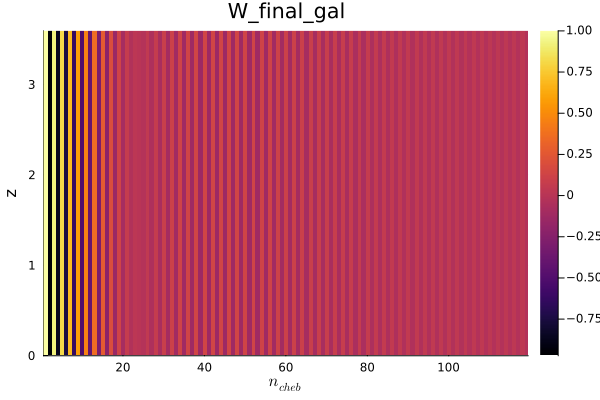

In [23]:
heatmap(1:n_cheb, z_range, W_tilde[8,1,:,:]./maximum(W_tilde[8,1,:,:]), xlabel=L"n_{cheb}", ylabel="z", title="W_final_gal")

$\tilde W(k,k_1)$ (like $\tilde W(k,k_2)$) represents the term: \
$\tilde W_{i,p,l}^{(\ell)} = \sum_{m=1}^{N_k} w_{k_m} T_{\ell}(k_m) j_{\ell}(\chi_i k_m) j_{\ell}(\chi_p k_m) $ \
it describes how much two shells at comoving distance $\chi_i$ and $\chi_p$ are correlated to the multipole $\ell$, weighted by the Chebyshev polynomial $T_{\ell}$ on the mode $k$.

In [24]:
npzwrite(joinpath(quantity_subdir, "chebcoefs/cheb_coeff_shear.npy"), cheb_coeff_shear)
npzwrite(joinpath(quantity_subdir, "chebcoefs/cheb_coeff_gal.npy"), cheb_coeff_gal)

In [25]:
@tullio W_final_gal[i, j, k] := W_tilde[i, j, k, l] * cheb_coeff_gal[l];
@tullio W_final_shear[i, j, k] := W_tilde[i, j, k, l] * cheb_coeff_shear[l];

In [26]:
println("Size of W_final_gal: ", size(W_final_gal))

Size of W_final_gal: (100, 96, 96)


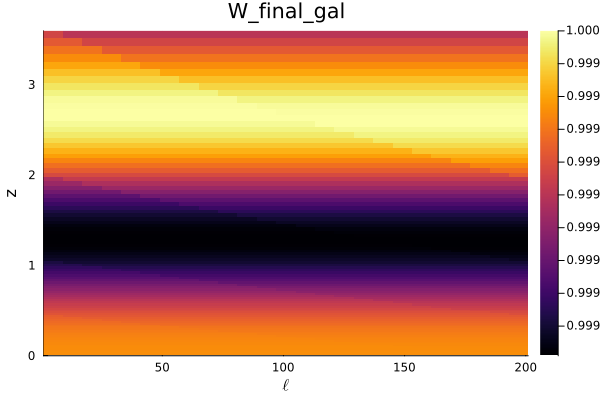

In [27]:
heatmap(ℓ, z_range, W_final_gal[:,10,:]./maximum(W_final_gal[:,10,:]), xlabel=L"\ell", ylabel="z", title="W_final_gal")

In [28]:
npzwrite(joinpath(output_dir, "W_final_gal.npy"), W_final_gal)
npzwrite(joinpath(output_dir, "W_final_shear.npy"), W_final_shear)

In [29]:
#3D matter power spectrum
pk_dict = npzread("blast_code/data/pk.npz")
Pklin = pk_dict["pk_lin"]
Pknonlin = pk_dict["pk_nl"]
k = pk_dict["k"]
z = pk_dict["z"];
#Interpolating the power spectrum: Linear P(k) - Non-linear P(k)
y = LinRange(log10(first(k)),log10(last(k)), length(k))
x = LinRange(first(z), last(z), length(z))
InterpPmm = Interpolations.interpolate(log10.(Pklin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm = scale(InterpPmm, (x, y))
InterpPmm = Interpolations.extrapolate(InterpPmm, Line())
InterpPmm_nl = Interpolations.interpolate(log10.(Pknonlin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm_nl = scale(InterpPmm_nl, x, y)
InterpPmm_nl = Interpolations.extrapolate(InterpPmm_nl, Line())
power_spectrum(k, χ1, χ2) = @. sqrt(10^InterpPmm(z_of_χ(χ1),log10(k)) * 10^InterpPmm(z_of_χ(χ2),log10(k)))
power_spectrum_nl(k, χ1, χ2) = @. sqrt(10^InterpPmm_nl(z_of_χ(χ1),log10(k)) * 10^InterpPmm_nl(z_of_χ(χ2),log10(k)));
# plot(k, power_spectrum.(k, 1000.0, 1000.0), 
#      label="Linear P(k)", 
#      xscale=:log10, 
#      yscale=:log10, 
#      title=L"$P(k)$ at $z=0$", titlefontsize=20,
#      xlabel=L"$k \; (h/\mathrm{Mpc})$", 
#      ylabel=L"$P(k) \; ((\mathrm{Mpc}/h)^3)$", 
#      labelfontsize=15)
# plot!(k, power_spectrum_nl.(k, 1000.0, 1000.0), 
#       label="Non-linear P(k)", 
#       xscale=:log10, 
#       yscale=:log10,
#       size=(800,600),
#       legendfontsize=10)

get_clencurt_grid produces the node of Clenshaw-Curtis mapped on [$k_{min}$, $k_{max}$]. \
get_clencurt_weights produces the corresponding quadrature weights scaled to the interval [-1,1]. \

In [30]:
Nz = n_chi
k_grid = Blast.get_clencurt_grid(kmin, kmax, Nz)
Pk_grid = power_spectrum.(k_grid, kmin, kmax)
w_k = Blast.get_clencurt_weights(kmin, kmax, Nz)
weight_gal = w_k .* k_grid.^2 .* Pk_grid 
;

In [31]:
abstract type AbstractProbe end
struct Galaxy <: AbstractProbe end
struct Shear <: AbstractProbe end
factorial_frac(ℓ) = (ℓ + 2.0) * (ℓ + 1.0) * ℓ * (ℓ - 1.0)
get_ell_prefactor(::Galaxy, ::Galaxy, ℓ) = @. (2 / π) * ones(length(ℓ))
get_ell_prefactor(::Galaxy, ::Shear,  ℓ) = @. (2 / π) * sqrt(factorial_frac(ℓ))
get_ell_prefactor(::Shear,  ::Galaxy, ℓ) = @. (2 / π) * sqrt(factorial_frac(ℓ))
get_ell_prefactor(::Shear,  ::Shear,  ℓ) = @. (2 / π) * factorial_frac(ℓ)
pref_gg = get_ell_prefactor(Galaxy(), Galaxy(), ℓ)
pref_gg = reduce(vcat, pref_gg)
pref_gs = get_ell_prefactor(Galaxy(), Shear(), ℓ)
pref_gs = reduce(vcat, pref_gs)
pref_gg = reduce(vcat, pref_gg)
pref_ss = get_ell_prefactor(Shear(), Shear(), ℓ)
pref_ss = reduce(vcat, pref_ss);

In [32]:
println("SIZES")
println("weight_gal -> ", size(weight_gal))
println("W_final_gal -> ", size(W_final_gal), "\nW_final_shear -> ", size(W_final_shear))
println("pref_gg -> ", size(pref_gg), "\npref_ss -> ", size(pref_ss), "\npref_gs -> ", size(pref_gs))

SIZES
weight_gal -> (96,)
W_final_gal -> (100, 96, 96)
W_final_shear -> (100, 96, 96)
pref_gg -> (100,)
pref_ss -> (100,)
pref_gs -> (100,)


In [33]:
S_lkk_gg = zeros(Float64, size(W_final_gal, 3), size(W_final_gal, 3), length(ℓ))
@tullio S_lkk_gg[kp, kpp, li] = pref_gg[li] * weight_gal[k] * W_final_gal[li, k, kp] * W_final_gal[li, k, kpp]
# S_lkk_ss = zeros(Float64, size(W_final_shear, 3), size(W_final_shear, 3), length(ℓ))
# @tullio S_lkk_ss[kp, kpp, li] = pref_ss[li] * weight_shear[k] * W_final_shear[li, k, kp] * W_final_shear[li, k, kpp] * Δk
# S_lkk_gs = zeros(Float64, size(W_final_shear, 3), size(W_final_gal, 3), length(ℓ))
# @tullio S_lkk_gs[kp, kpp, li] = pref_gs[li] * weight_gal_shear[k] * W_final_shear[li, k, kp] * W_final_gal[li, k, kpp] * Δk;
;

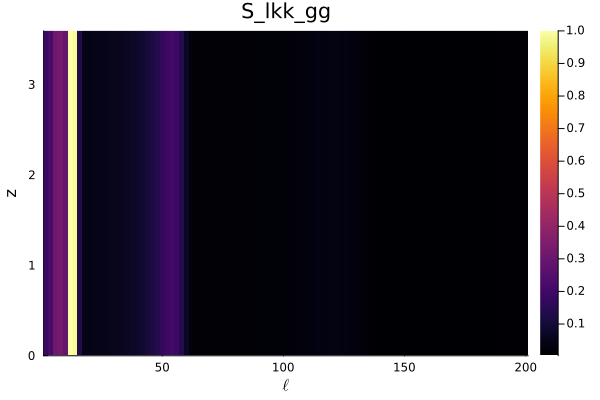

In [34]:
heatmap(ℓ, z_range, S_lkk_gg[3,:,:]/maximum(S_lkk_gg[3,:,:]), xlabel=L"\ell", ylabel="z", title="S_lkk_gg")

In [35]:
npzwrite(joinpath(quantity_subdir, "Sl/S_lkk_gg.npy"), S_lkk_gg)
# npzwrite(joinpath(quantity_subdir, "Sl/S_lkk_ss.npy"), S_lkk_ss)
# npzwrite(joinpath(quantity_subdir, "Sl/S_lkk_gs.npy"), S_lkk_gs)
;

In [36]:
println("Size of S_l (kp, kpp) (gal-gal):  ", size(S_lkk_gg))
# println("Size of S_l (kp, kpp) (shear-shear):  ", size(S_lkk_ss))
# println("Size of S_l (kp, kpp) (shear-gal):  ", size(S_lkk_gs))

Size of S_l (kp, kpp) (gal-gal):  (96, 96, 100)


In [37]:
i = Nz
j = Nz
k1 = k_grid[i]
k2 = k_grid[j]
;

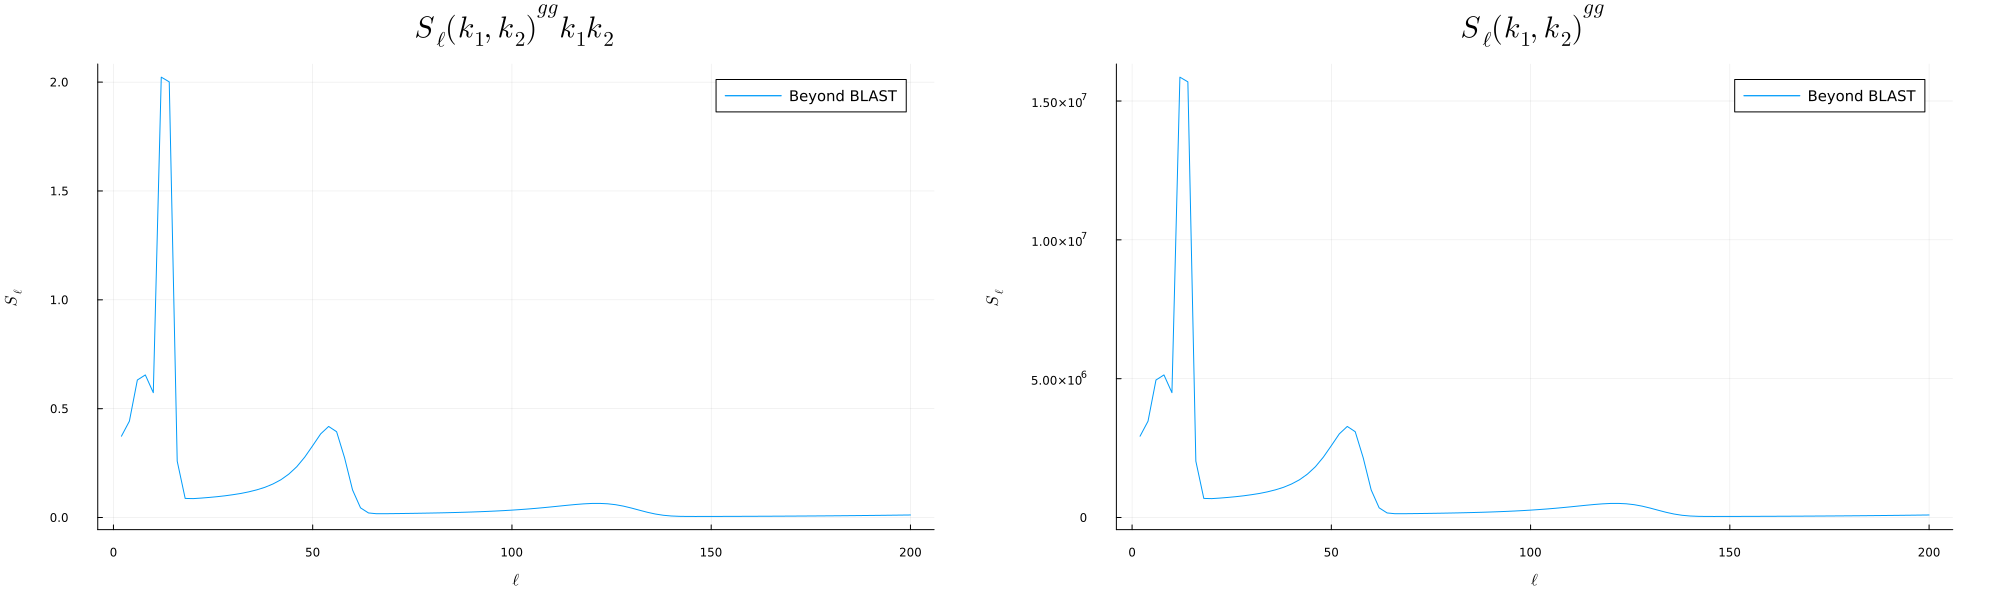

In [41]:
# plot
i = 1
j = 1
p1 =  plot(ℓ, k1 * k2 * S_lkk_gg[i,j,:], label="Beyond BLAST", xlabel=L"\ell", ylabel=L"S_\ell", title=L"S_\ell(k_1, k_2)^{gg} k_1 k_2")
p2 =  plot(ℓ, S_lkk_gg[i,j,:], label="Beyond BLAST", xlabel=L"\ell", ylabel=L"S_\ell", title=L"S_\ell(k_1, k_2)^{gg}")

plot(p1, p2, layout = (1, 2), size=(2000, 600), titlefontsize=20, legendfontsize=10, margin = 10mm)

In [42]:
savefig(joinpath(plot_subdir, "Sl_plots/S_l_plot_gg_and_k1k2.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_06_25_153308/plots/Sl_plots/S_l_plot_gg_and_k1k2.png"

In [53]:
a = 96
println(k_grid[a])
b = 95
println(k_grid[b])
c = 94
println(k_grid[c])
d = 90
println(k_grid[d])

0.0003571428607137071
0.004562757986631638
0.01717500459670429
0.15127697870416323


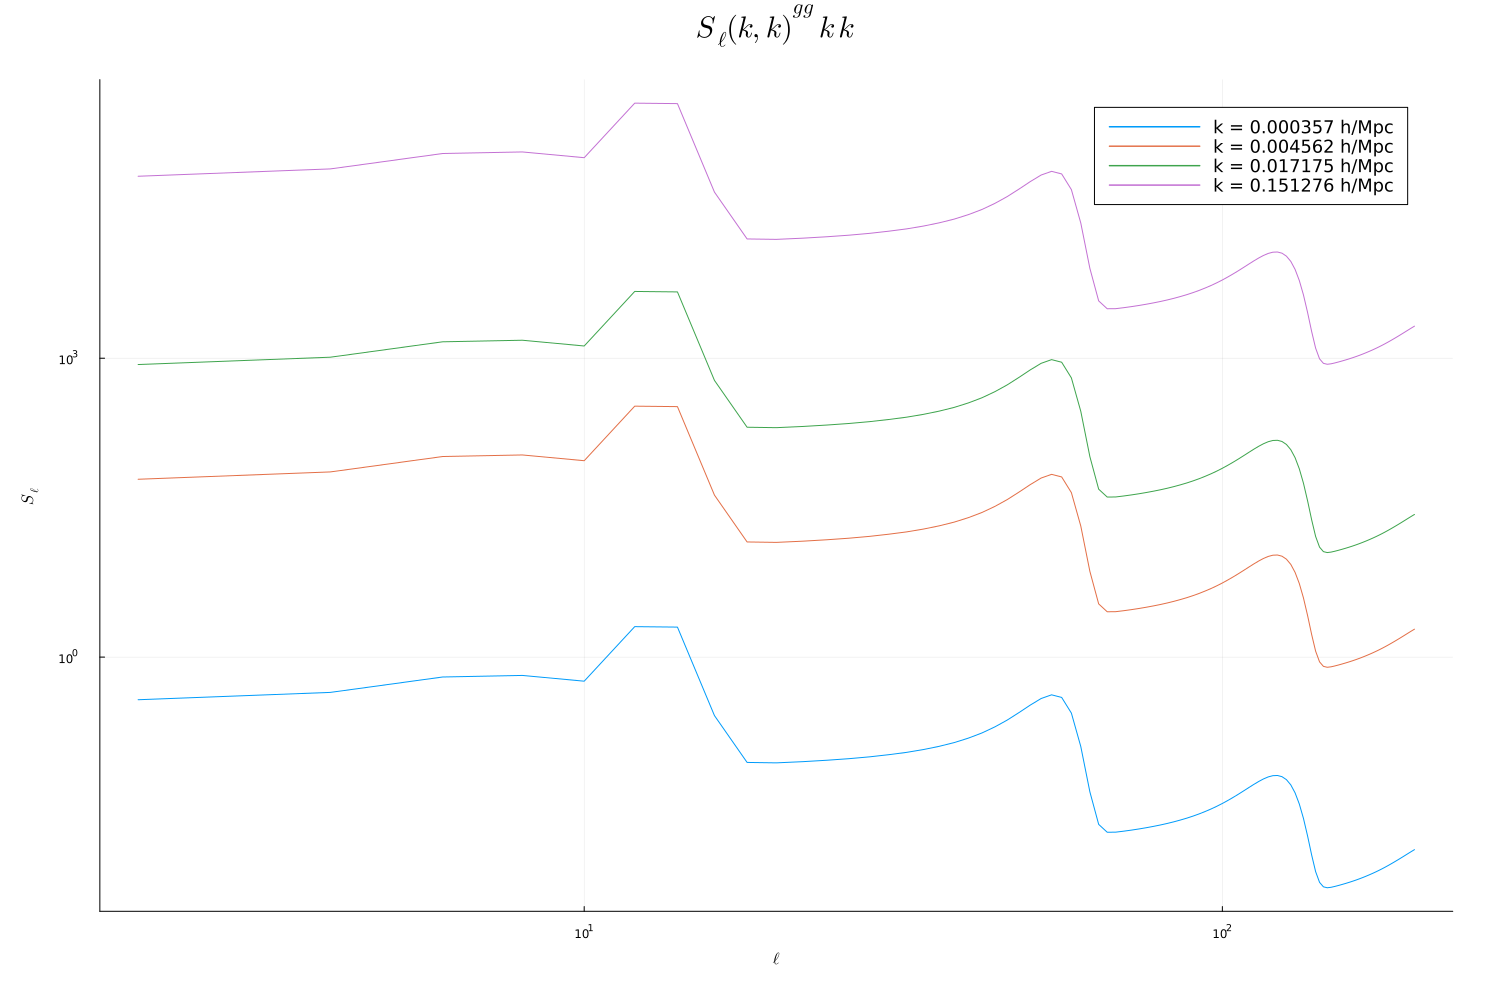

In [69]:
i = 1
j = 1

p = plot(ℓ, k_grid[a]^2 .* S_lkk_gg[i,j,:],
    label="k = 0.000357 h/Mpc",
    xlabel=L"\ell",
    ylabel=L"S_\ell",
    title=L"S_\ell(k, k)^{gg} \, k\,k")
plot!(p, ℓ, k_grid[b]^2 .* S_lkk_gg[i,j,:],
    label="k = 0.004562 h/Mpc")
plot!(p, ℓ, k_grid[c]^2 .* S_lkk_gg[i,j,:],
    label="k = 0.017175 h/Mpc")
plot!(p, ℓ, k_grid[d]^2 .* S_lkk_gg[i,j,:],
    label="k = 0.151276 h/Mpc")
plot!(p,
    yscale=:log10,
    size=(1500, 1000),
    titlefontsize=20,
    legendfontsize=12,
    margin=10mm)
plot!(p, xscale=:log10, yscale=:log10)

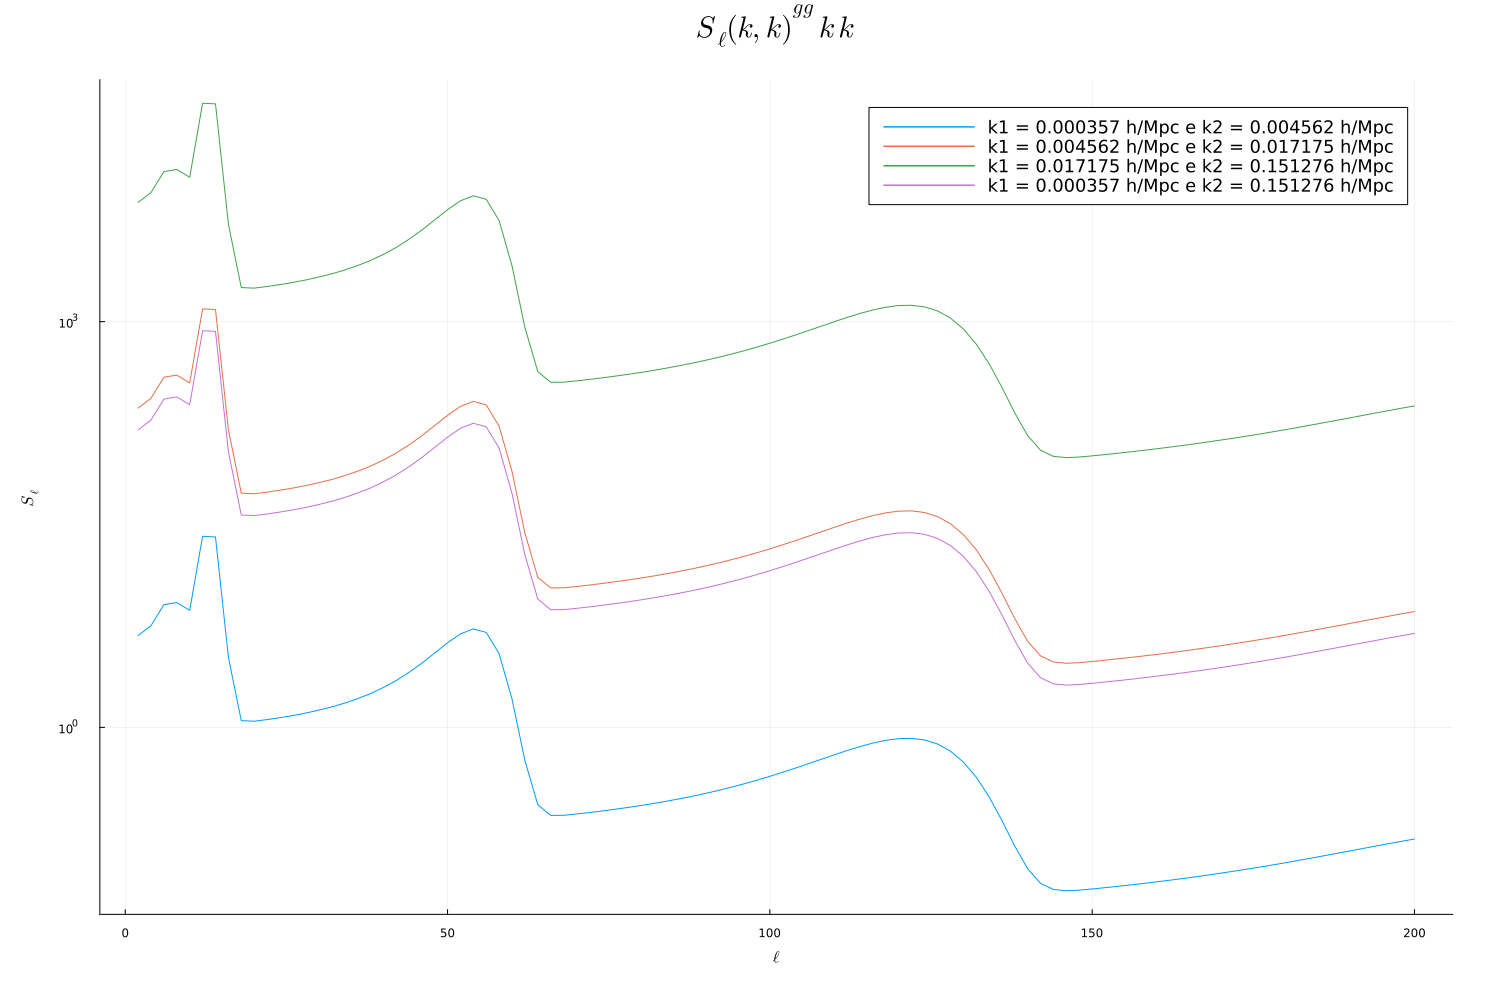

In [66]:
i = 1
j = 1

p = plot(ℓ, k_grid[a]*k_grid[b] .* S_lkk_gg[i,j,:],
    label="k1 = 0.000357 h/Mpc e k2 = 0.004562 h/Mpc",
    xlabel=L"\ell",
    ylabel=L"S_\ell",
    title=L"S_\ell(k, k)^{gg} \, k\,k")
plot!(p, ℓ, k_grid[b]*k_grid[c] .* S_lkk_gg[i,j,:],
    label="k1 = 0.004562 h/Mpc e k2 = 0.017175 h/Mpc")
plot!(p, ℓ, k_grid[c]*k_grid[d] .* S_lkk_gg[i,j,:],
    label="k1 = 0.017175 h/Mpc e k2 = 0.151276 h/Mpc")
plot!(p, ℓ, k_grid[a]*k_grid[d] .* S_lkk_gg[i,j,:],
    label="k1 = 0.000357 h/Mpc e k2 = 0.151276 h/Mpc")
plot!(p,
    yscale=:log10,
    size=(1500, 1000),
    titlefontsize=20,
    legendfontsize=12,
    margin=10mm)


In [39]:
plot(
    ℓ,
    k1 * k2 * S_lkk_gg[1, 1, :] .* ℓ .* (ℓ .+ 1),
    label = "Beyond BLAST",
    xlabel = L"\ell",
    ylabel = L"\ell(\ell+1)S_\ell",
    title = L"\ell(\ell+1)S_\ell^{gg}(k_1,k_2)",
    markersize=4,
    size = (1000, 600),
    titlefontsize=20,
    labelfontsize=15,
    margin = 5mm
)
savefig(joinpath(plot_subdir, "Sl_plots/S_l_plot_ll+1.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_06_25_153308/plots/Sl_plots/S_l_plot_ll+1.png"

In [40]:
params_run = Dict(
    "x_min" => x_min,
    "x_max" => x_max,
    "n_chi" => n_chi,
    "zmin" => zmin,
    "zmax" => zmax,
    "kmin" => kmin,
    "kmax" => kmax,
    "n_cheb" => n_cheb,
    "N" => N,
    "ℓ" => length(ℓ)
)

open(joinpath(output_dir, "config.json"), "w") do dictio
    JSON.print(dictio, params_run, 4)
end

println("Data brought to safety in folder: ", output_dir)

Data brought to safety in folder: out/runs/run_2026_06_25_153308
